# Hierarchical Clustering over K-Means Reader Zones

K-Means builds book-level reader-interest zones. Hierarchical clustering is then applied to the exported K-Means centroids for `k=100` to study how those zones relate to each other.

In [1]:
from __future__ import annotations

import re
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score

KMEANS_K = 100
RANDOM_STATE = 42
LINKAGE_METHOD = "ward"
DISTANCE_METRIC = "euclidean"
HIERARCHICAL_GROUPS = [5, 10, 15, 20, 25]
FINAL_N_GROUPS = 10


def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for path in [current, *current.parents]:
        if (path / "data" / "outputs" / "clustering" / f"kmeans_model_k{KMEANS_K}.joblib").exists():
            return path
    raise FileNotFoundError("Could not find project root from current working directory.")


PROJECT_ROOT = find_project_root()
OUTPUT_DIR = PROJECT_ROOT / "data" / "outputs" / "clustering"
KMEANS_MODEL_PATH = OUTPUT_DIR / f"kmeans_model_k{KMEANS_K}.joblib"
BOOK_CLUSTERS_PATH = OUTPUT_DIR / f"book_clusters_k{KMEANS_K}.parquet"
KMEANS_SUMMARY_PATH = OUTPUT_DIR / f"cluster_summary_k{KMEANS_K}.csv"
KMEANS_TERMS_PATH = OUTPUT_DIR / f"cluster_top_titles_terms_k{KMEANS_K}.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Output dir: {OUTPUT_DIR}")
print(f"K-Means model: {KMEANS_MODEL_PATH}")

Project root: /home/nakato/projects/BigBook
Output dir: /home/nakato/projects/BigBook/data/outputs/clustering
K-Means model: /home/nakato/projects/BigBook/data/outputs/clustering/kmeans_model_k100.joblib


In [2]:
def save_and_display_plot(path: Path) -> None:
    plt.savefig(path, dpi=150)
    plt.close()
    display(Image(filename=str(path)))


def validate_kmeans_model(model: object) -> None:
    n_clusters = getattr(model, "n_clusters", None)
    if n_clusters != KMEANS_K:
        raise ValueError(f"Expected K-Means k={KMEANS_K}, found k={n_clusters}.")

    random_state = getattr(model, "random_state", None)
    if random_state != RANDOM_STATE:
        raise ValueError(f"Expected random_state={RANDOM_STATE}, found random_state={random_state}.")

    if not hasattr(model, "cluster_centers_"):
        raise ValueError("The exported K-Means model has no cluster_centers_.")


def load_optional_csv(path: Path) -> pd.DataFrame | None:
    if not path.exists():
        print(f"Optional file not found: {path}")
        return None
    return pd.read_csv(path)


kmeans_model = joblib.load(KMEANS_MODEL_PATH)
validate_kmeans_model(kmeans_model)

centroids = kmeans_model.cluster_centers_.astype(np.float32)
kmeans_clusters = np.arange(KMEANS_K, dtype=np.int32)
kmeans_summary = load_optional_csv(KMEANS_SUMMARY_PATH)
kmeans_terms = load_optional_csv(KMEANS_TERMS_PATH)

print(kmeans_model)
print(f"Centroids shape: {centroids.shape}")
print(f"Random state: {kmeans_model.random_state}")
print(f"Linkage: {LINKAGE_METHOD}, metric: {DISTANCE_METRIC}")

KMeans(n_clusters=100, random_state=42)
Centroids shape: (100, 173)
Random state: 42
Linkage: ward, metric: euclidean


In [3]:
linkage_matrix = linkage(
    centroids,
    method=LINKAGE_METHOD,
    metric=DISTANCE_METRIC,
    optimal_ordering=True,
)

linkage_path = OUTPUT_DIR / f"hclust_linkage_k{KMEANS_K}_{LINKAGE_METHOD}.npy"
np.save(linkage_path, linkage_matrix)
print(f"Saved {linkage_path}")

merge_profile = pd.DataFrame(
    linkage_matrix,
    columns=["left_node", "right_node", "distance", "n_kmeans_clusters"],
)
merge_profile.insert(0, "merge_step", np.arange(1, len(merge_profile) + 1))
merge_profile_path = OUTPUT_DIR / f"hclust_merge_profile_k{KMEANS_K}_{LINKAGE_METHOD}.csv"
merge_profile.to_csv(merge_profile_path, index=False)
print(f"Saved {merge_profile_path}")

display(merge_profile.tail(15).round(4))

Saved /home/nakato/projects/BigBook/data/outputs/clustering/hclust_linkage_k100_ward.npy
Saved /home/nakato/projects/BigBook/data/outputs/clustering/hclust_merge_profile_k100_ward.csv


,merge_step,left_node,right_node,distance,n_kmeans_clusters
84,85,148.0,179.0,2.5378,16.0
85,86,184.0,155.0,2.8984,18.0
86,87,174.0,185.0,3.0940,26.0
87,88,182.0,176.0,3.3164,15.0
88,89,175.0,186.0,3.4441,35.0
89,90,43.0,10.0,3.7175,2.0
90,91,181.0,188.0,3.7275,45.0
91,92,167.0,190.0,4.3052,49.0
92,93,191.0,187.0,4.9742,64.0
93,94,178.0,183.0,5.5922,30.0


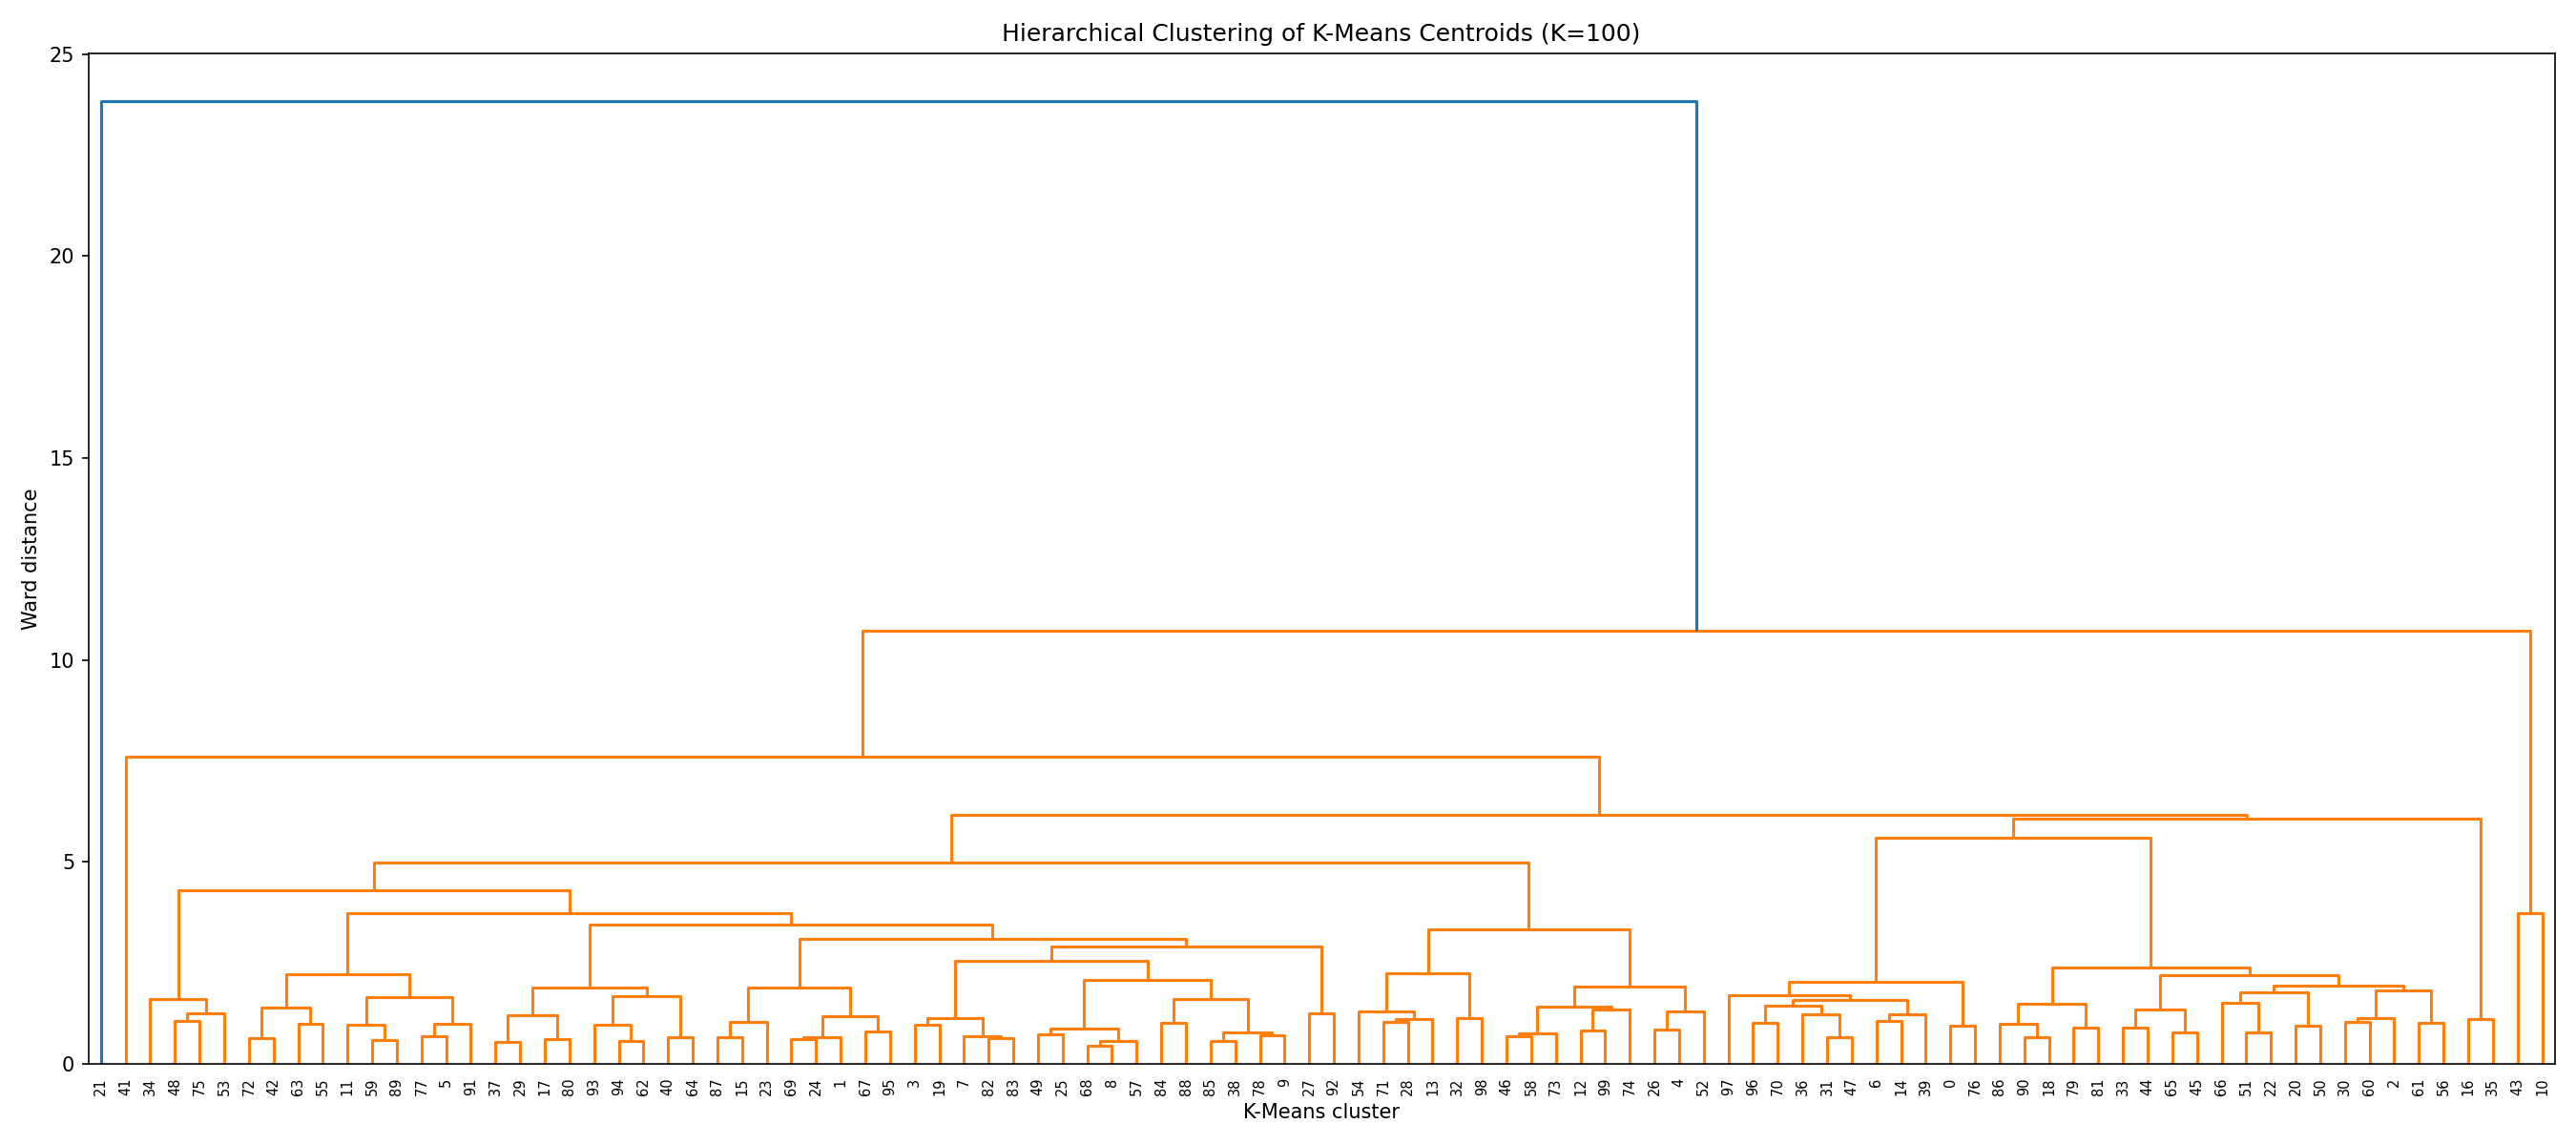

Saved /home/nakato/projects/BigBook/data/outputs/clustering/hclust_dendrogram_k100_ward.png


In [4]:
plt.figure(figsize=(18, 8))
dendrogram(
    linkage_matrix,
    labels=[str(cluster) for cluster in kmeans_clusters],
    leaf_rotation=90,
    leaf_font_size=7,
)
plt.title(f"Hierarchical Clustering of K-Means Centroids (K={KMEANS_K})")
plt.xlabel("K-Means cluster")
plt.ylabel("Ward distance")
plt.tight_layout()
dendrogram_path = OUTPUT_DIR / f"hclust_dendrogram_k{KMEANS_K}_{LINKAGE_METHOD}.png"
save_and_display_plot(dendrogram_path)
print(f"Saved {dendrogram_path}")

In [5]:
def relabel_by_smallest_kmeans_cluster(labels: np.ndarray) -> np.ndarray:
    ordered_groups = sorted(np.unique(labels), key=lambda label: kmeans_clusters[labels == label].min())
    mapping = {old_label: new_label for new_label, old_label in enumerate(ordered_groups)}
    return np.array([mapping[label] for label in labels], dtype=np.int32)


def centroid_group_labels(n_groups: int) -> np.ndarray:
    raw_labels = fcluster(linkage_matrix, t=n_groups, criterion="maxclust")
    return relabel_by_smallest_kmeans_cluster(raw_labels)


def centroid_group_size_stats(labels: np.ndarray) -> dict[str, float]:
    counts = pd.Series(labels).value_counts().sort_index()
    return {
        "min_kmeans_clusters": int(counts.min()),
        "max_kmeans_clusters": int(counts.max()),
        "mean_kmeans_clusters": float(counts.mean()),
        "median_kmeans_clusters": float(counts.median()),
    }


evaluation_rows = []
for n_groups in HIERARCHICAL_GROUPS:
    labels = centroid_group_labels(n_groups)
    actual_n_groups = int(pd.Series(labels).nunique())
    evaluation_rows.append(
        {
            "n_hierarchical_groups": n_groups,
            "actual_n_hierarchical_groups": actual_n_groups,
            "silhouette_on_centroids": float(silhouette_score(centroids, labels)),
            "davies_bouldin_on_centroids": float(davies_bouldin_score(centroids, labels)),
            "calinski_harabasz_on_centroids": float(calinski_harabasz_score(centroids, labels)),
            **centroid_group_size_stats(labels),
        }
    )

hclust_evaluation = pd.DataFrame(evaluation_rows)
evaluation_path = OUTPUT_DIR / f"hclust_cut_evaluation_k{KMEANS_K}_{LINKAGE_METHOD}.csv"
hclust_evaluation.to_csv(evaluation_path, index=False)
print(f"Saved {evaluation_path}")
display(hclust_evaluation.round(4))

all_cut_labels = pd.DataFrame({"cluster": kmeans_clusters})
for n_groups in HIERARCHICAL_GROUPS:
    all_cut_labels[f"h_{n_groups}"] = centroid_group_labels(n_groups)

all_cut_labels_path = OUTPUT_DIR / f"hclust_centroid_groups_all_cuts_k{KMEANS_K}_{LINKAGE_METHOD}.csv"
all_cut_labels.to_csv(all_cut_labels_path, index=False)
print(f"Saved {all_cut_labels_path}")

Saved /home/nakato/projects/BigBook/data/outputs/clustering/hclust_cut_evaluation_k100_ward.csv


,n_hierarchical_groups,actual_n_hierarchical_groups,silhouette_on_centroids,davies_bouldin_on_centroids,calinski_harabasz_on_centroids,min_kmeans_clusters,max_kmeans_clusters,mean_kmeans_clusters,median_kmeans_clusters
0,5,5,0.1431,1.2300,58.6007,1,64,20.0000,2.0
1,10,10,0.1641,1.1219,47.5246,1,35,10.0000,7.0
2,15,15,0.1554,1.0079,42.9470,1,19,6.6667,6.0
3,20,20,0.1742,1.0512,38.1693,1,11,5.0000,4.0
4,25,25,0.1789,1.0634,35.1592,1,9,4.0000,4.0


Saved /home/nakato/projects/BigBook/data/outputs/clustering/hclust_centroid_groups_all_cuts_k100_ward.csv


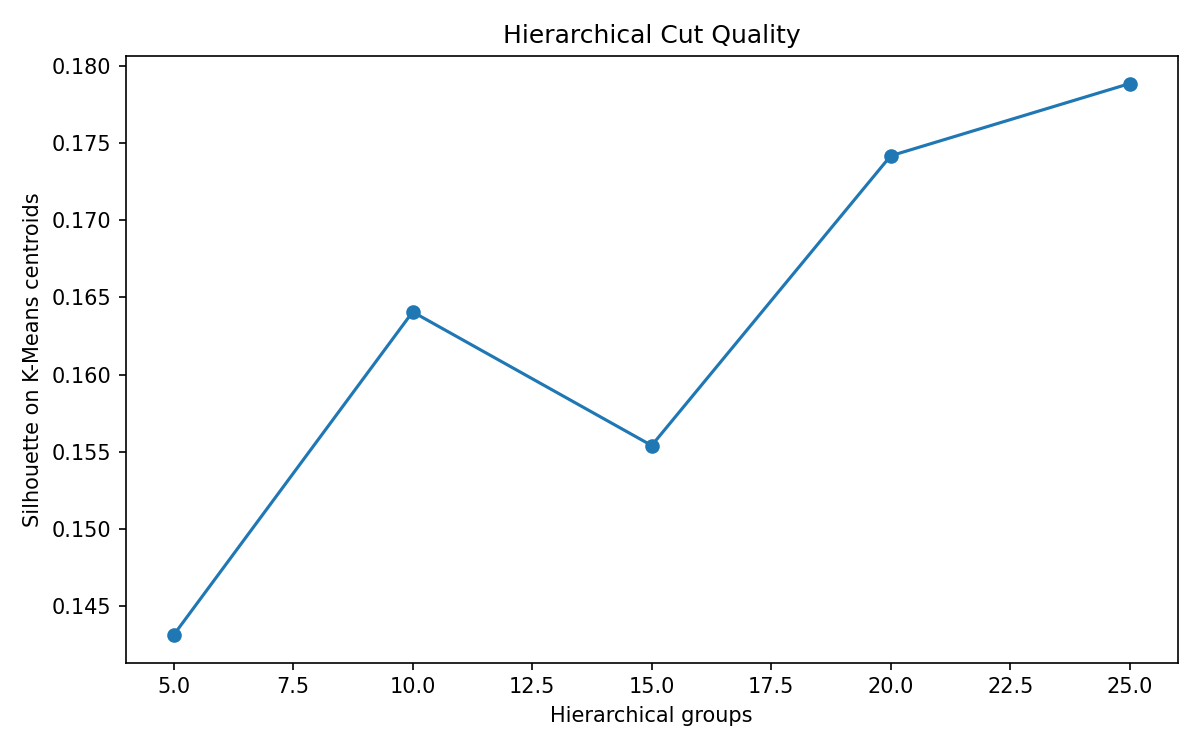

Saved /home/nakato/projects/BigBook/data/outputs/clustering/hclust_silhouette_by_groups_k100_ward.png


In [6]:
plt.figure(figsize=(8, 5))
plt.plot(
    hclust_evaluation["n_hierarchical_groups"],
    hclust_evaluation["silhouette_on_centroids"],
    marker="o",
)
plt.xlabel("Hierarchical groups")
plt.ylabel("Silhouette on K-Means centroids")
plt.title("Hierarchical Cut Quality")
plt.tight_layout()
quality_plot_path = OUTPUT_DIR / f"hclust_silhouette_by_groups_k{KMEANS_K}_{LINKAGE_METHOD}.png"
save_and_display_plot(quality_plot_path)
print(f"Saved {quality_plot_path}")

In [7]:
def representative_terms(values: pd.Series, limit: int = 20) -> str:
    tokens: list[str] = []
    for value in values.dropna().astype(str):
        tokens.extend(token for token in re.split(r"[|,]", value) if token)
    if not tokens:
        return ""
    return "|".join(pd.Series(tokens).value_counts().head(limit).index.tolist())


def representative_titles(values: pd.Series, limit: int = 12) -> str:
    titles: list[str] = []
    for value in values.dropna().astype(str):
        titles.extend(title.strip() for title in value.split(" | ") if title.strip())
    return " | ".join(titles[:limit])


final_labels = centroid_group_labels(FINAL_N_GROUPS)
centroid_groups = pd.DataFrame(
    {
        "cluster": kmeans_clusters,
        "h_cluster": final_labels,
    }
)

if kmeans_summary is not None:
    centroid_groups = centroid_groups.merge(kmeans_summary, on="cluster", how="left")
if kmeans_terms is not None:
    centroid_groups = centroid_groups.merge(kmeans_terms, on="cluster", how="left")

centroid_groups_path = OUTPUT_DIR / f"hclust_centroid_groups_k{KMEANS_K}_h{FINAL_N_GROUPS}_{LINKAGE_METHOD}.csv"
centroid_groups.to_csv(centroid_groups_path, index=False)
print(f"Saved {centroid_groups_path}")

agg_spec = {
    "cluster": lambda values: "|".join(values.astype(str)),
}
if "n_books" in centroid_groups.columns:
    agg_spec["n_books"] = "sum"
if "top_title_terms" in centroid_groups.columns:
    agg_spec["top_title_terms"] = representative_terms
if "representative_titles" in centroid_groups.columns:
    agg_spec["representative_titles"] = representative_titles

h_summary = centroid_groups.groupby("h_cluster", sort=True).agg(agg_spec).reset_index()
h_summary = h_summary.rename(columns={"cluster": "kmeans_clusters"})
h_summary.insert(
    1,
    "n_kmeans_clusters",
    h_summary["kmeans_clusters"].str.count(r"\|").add(1).astype(np.int32),
)
if "n_books" in h_summary.columns:
    h_summary["percentage"] = h_summary["n_books"] / h_summary["n_books"].sum() * 100

h_summary_path = OUTPUT_DIR / f"hclust_summary_k{KMEANS_K}_h{FINAL_N_GROUPS}_{LINKAGE_METHOD}.csv"
h_summary.to_csv(h_summary_path, index=False)
print(f"Saved {h_summary_path}")

with pd.option_context("display.max_rows", 120, "display.max_colwidth", 160):
    display(h_summary.round({"percentage": 4}) if "percentage" in h_summary.columns else h_summary)

Saved /home/nakato/projects/BigBook/data/outputs/clustering/hclust_centroid_groups_k100_h10_ward.csv
Saved /home/nakato/projects/BigBook/data/outputs/clustering/hclust_summary_k100_h10_ward.csv


,h_cluster,n_kmeans_clusters,kmeans_clusters,n_books,top_title_terms,representative_titles,percentage
0,0,11,0|6|14|31|36|39|47|70|76|96|97,6969,trilogy|dark|love|you|chronicles|mystery|vampire|bride|dead|night|billionaire|brothers|life|murder|girl|heart|blood|witch|saga|darkness,"Bear My Baby (Shifter Squad Six, #1) | Deliciously Mated (Ouachita Mountain Shifters, #1) | A Jaguar's Touch (Awakening Pride, #5) | Kraven (VLG, #2) | Pixi...",6.4392
1,1,35,1|3|7|8|9|15|17|19|23|24|25|27|29|37|38|40|49|57|62|64|67|68|69|78|80|82|83|84|85|87|88|92|93|94|95,53468,you|love|dark|trilogy|chronicles|dead|brothers|girl|world|mystery|murder|death|mysteries|story|war|history|heart|blood|life|billionaire,"Eleven (Brandon Fisher FBI, #1) | Waiting for Wednesday (Frieda Klein, #3) | Live to Tell (Live to Tell #1) | The Fixer (Mort Grant, #1) | A Deeper Darkness...",49.4036
2,2,19,2|18|20|22|30|33|44|45|50|51|56|60|61|65|66|79|81|86|90,17843,you|love|world|dark|life|story|war|dead|american|history|vampire|chronicles|blood|death|hunter|trilogy|mystery|murder|mysteries|night,"Conquer Your Love (Surrender Your Love, #2) | Surrender Your Love (Surrender Your Love, #1) | Surrender to Sultry (Sultry Springs, #3) | Welcome to Paradise...",16.4866
3,3,15,4|12|13|26|28|32|46|52|54|58|71|73|74|98|99,14674,girl|chronicles|you|trilogy|love|dark|vampire|all|little|blood|life|summer|boy|harry|night|queen|academy|divergent|girls|last,"Mortality (The Hitchhiker Strain, #1) | Over You | Down to the Bone | Summer State of Mind (Whispering Pines, #2) | By Any Other Name | All the Broken Piece...",13.5585
4,4,10,5|11|42|55|59|63|72|77|89|91,11198,dark|vampire|love|trilogy|blood|mystery|wolf|death|pack|dragon|chronicles|lady|moon|alpha|hunter|night|black|midnight|darkness|lords,"Unforgiven (The Forbidden Bond, #2) | An Unlucky Moon (Dante's Circle, #3) | One Bite (Blood Prince, #2) | Charred Tears (Heart of Fire, #2) | Hunter's Moon...",10.3468
5,5,2,10|43,485,stories|tales|fantasy|sword|sorceress|new|horror|best|year|collection|mammoth|blood|anthology|love|romance|darkover|realms|fiction,"The Mammoth Book of Vampire Stories by Women | Halloween | Wings of Fire | Some of the Best from Tor.com: 2014 | Blood Lite III: Aftertaste (Blood Lite, #3;...",0.4481
6,6,2,16|35,1073,mystery|you|fire|girl|trilogy|night|dark|blood|midnight|dead|never|red|love|bear|her|chronicles|brothers|broken|bad|billionaire,"The Lie Tree | City of Souls (Signs of the Zodiac, #4) | Fearless (Pax Arcana, #3) | Moonlight Masquerade (Edilean, #8) | The Touch of Twilight (Signs of th...",0.9914
7,7,1,21,7,complete|outlander|dark|hunters|collection|thus|far|hunter|worm|malazan|fallen|wheel,"The Dark-Hunters: The Collection Thus Far (Dark-Hunter, #1-22) | The Complete Malazan Book of the Fallen | The Outlander Series (Outlander, #1-7) | The Comp...",0.0065
8,8,4,34|48|53|75,2463,man|world|mystery|time|saga|chronicles|lord|vampire|rings|cycle|stories|nancy|drew|clue|hardy|boys|parker|little|house|fairy,"The Clue of the Dancing Puppet (Nancy Drew Mystery Stories, #39) | Hag's Nook (Dr. Gideon Fell, #1) | The Secret of the Old Clock (Nancy Drew Mystery Storie...",2.2758
9,9,1,41,47,harry|potter|city|collection|complete|song|fire|set|ice|boxed|mistborn|twilight,"The Mortal Instruments, the Complete Collection: City of Bones; City of Ashes; City of Glass; City of Fallen Angels; City of Lost Souls; City of Heavenly Fi...",0.0434


In [8]:
if BOOK_CLUSTERS_PATH.exists():
    book_clusters = pd.read_parquet(BOOK_CLUSTERS_PATH)
    book_hclusters = book_clusters.merge(
        centroid_groups[["cluster", "h_cluster"]],
        on="cluster",
        how="left",
        validate="many_to_one",
    )
    if book_hclusters["h_cluster"].isna().any():
        raise ValueError("Some books did not receive a hierarchical cluster.")

    book_hclusters["h_cluster"] = book_hclusters["h_cluster"].astype(np.int32)
    book_hclusters_path = OUTPUT_DIR / f"book_hclusters_k{KMEANS_K}_h{FINAL_N_GROUPS}_{LINKAGE_METHOD}.parquet"
    book_hclusters.to_parquet(book_hclusters_path, index=False)
    print(f"Saved {book_hclusters_path}")
    display(book_hclusters.head())
else:
    print(f"Book-level K-Means assignments not found: {BOOK_CLUSTERS_PATH}")

Saved /home/nakato/projects/BigBook/data/outputs/clustering/book_hclusters_k100_h10_ward.parquet


,book_id,cluster,h_cluster
0,1,54,3
1,10,41,9
2,10000063,23,1
3,10000191,3,1
4,10000269,57,1


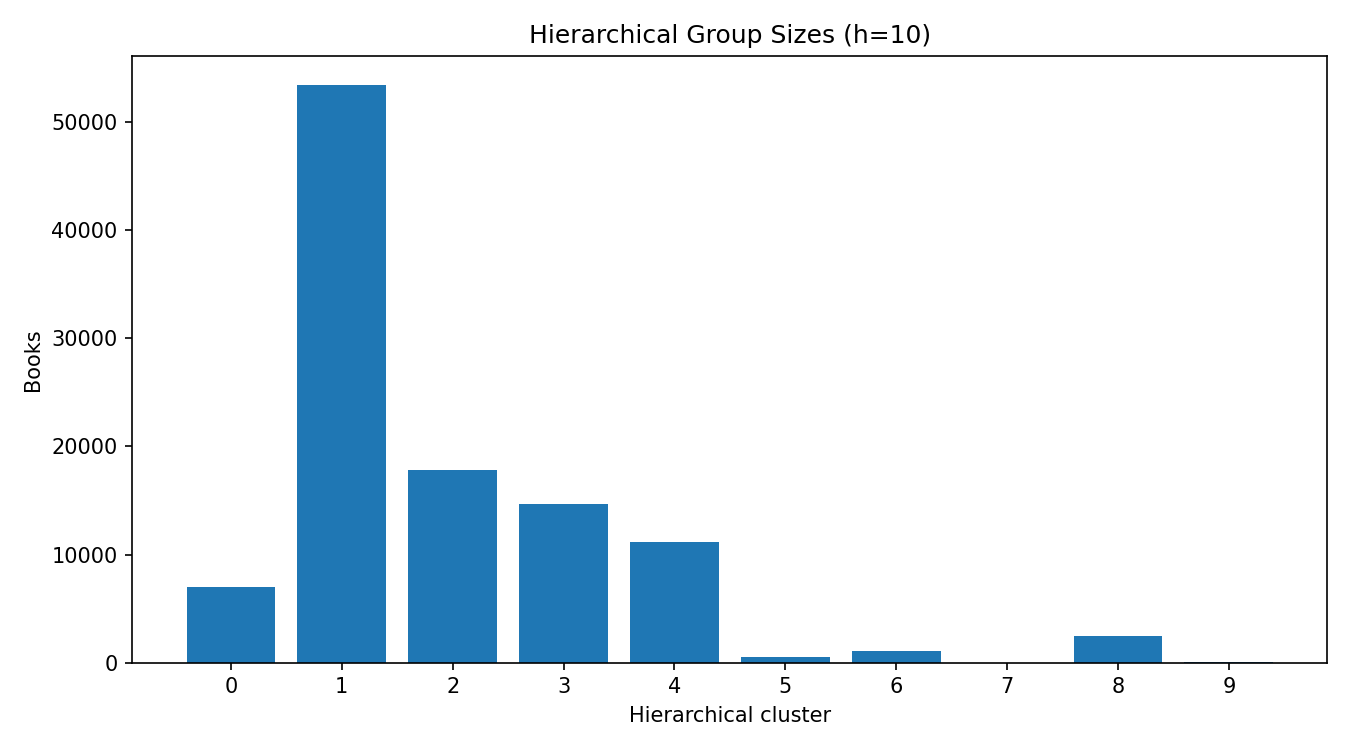

Saved /home/nakato/projects/BigBook/data/outputs/clustering/hclust_group_sizes_k100_h10_ward.png


In [9]:
if "n_books" in h_summary.columns:
    plot_data = h_summary.sort_values("h_cluster")
    y_values = plot_data["n_books"]
    y_label = "Books"
else:
    plot_data = h_summary.sort_values("h_cluster")
    y_values = plot_data["n_kmeans_clusters"]
    y_label = "K-Means clusters"

plt.figure(figsize=(9, 5))
plt.bar(plot_data["h_cluster"].astype(str), y_values)
plt.xlabel("Hierarchical cluster")
plt.ylabel(y_label)
plt.title(f"Hierarchical Group Sizes (h={FINAL_N_GROUPS})")
plt.tight_layout()
size_plot_path = OUTPUT_DIR / f"hclust_group_sizes_k{KMEANS_K}_h{FINAL_N_GROUPS}_{LINKAGE_METHOD}.png"
save_and_display_plot(size_plot_path)
print(f"Saved {size_plot_path}")